<a href="https://colab.research.google.com/github/tikik/HR-and-R/blob/First/r_practice_hr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> 💡 **"Always be the first to question the data."**  
> — *CEO Alexander Wang, as noted in his latest interview*

Before delivering any analysis, **we hand-check every dataset**. This isn’t just a step — it’s a mindset. As Wang emphasized, data analysts must be more than number-pushers: they must **own the story** behind the data.

---

### ✅ Our 5-Step Hand-Check Ritual

1. **Scan for Data Integrity Issues**  
   Use `str()`, `summary()`, and missing value checks to quickly catch:
   - Typos
   - Impossible values (e.g., Age = 120)
   - Missing or inconsistent entries

2. **Hand-Check Distributions Before Modeling**  
   Visualize with boxplots, stripcharts, histograms, and density plots. Ask yourself:
   - Do these patterns make sense?
   - Are outliers real or data entry errors?

3. **Spot Suspicious or Dummy Variables**  
   Manually check for:
   - Constant columns like `StandardHours` or `EmployeeCount`
   - Columns with a single unique value that add no insight

4. **Check Consistency in Group Labels**  
   Look out for:
   - Typos in categories (e.g., `"Sales"` vs `"Sales "`)
   - Inconsistent naming conventions across columns

5. **Review a Few Random Rows by Eye**  
   Literally *look* at the data.
   - Would you be confident showing these to a client?
   - Can you explain any row without hesitation?

---

### 🔍 Why Hand-Check?

- ✅ Catch **typos and outliers** *before* your client does  
- 🧹 Avoid modeling with **garbage variables**  
- 🧠 Turn **strange patterns into explained stories**, not surprises  

---

### 🧭 Final Tip:

> When in doubt, assume your client will ask:  
> “**Can you explain this number to me?**”  
> — and you should be able to say **yes**, confidently.


In [ ]:
install.packages(c("tidyverse", "DataExplorer", "skimr", "corrplot"))
library(tidyverse)
library(DataExplorer)
library(skimr)
library(corrplot)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘plyr’, ‘data.tree’, ‘igraph’, ‘reshape2’, ‘gridExtra’, ‘networkD3’


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ purrr     1.0.4
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
corrplot 0.95 loaded



Dont want to download too many randonm packages like, readr?


In [ ]:
hrdata <- readr::read_csv("/content/hr.csv")

Rows: 1470 Columns: 35
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (9): Attrition, BusinessTravel, Department, EducationField, Gender, Job...
dbl (26): Age, DailyRate, DistanceFromHome, Education, EmployeeCount, Employ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:
# Skimming through this dataset, this time we load readr
library(readr)
hrdata <- read.csv("/content/hr.csv")
str(hrdata)
head(hrdata)
glimpse(hrdata)

'data.frame':	1470 obs. of  35 variables:
 $ Age                     : int  41 49 37 33 27 32 59 30 38 36 ...
 $ Attrition               : chr  "Yes" "No" "Yes" "No" ...
 $ BusinessTravel          : chr  "Travel_Rarely" "Travel_Frequently" "Travel_Rarely" "Travel_Frequently" ...
 $ DailyRate               : int  1102 279 1373 1392 591 1005 1324 1358 216 1299 ...
 $ Department              : chr  "Sales" "Research & Development" "Research & Development" "Research & Development" ...
 $ DistanceFromHome        : int  1 8 2 3 2 2 3 24 23 27 ...
 $ Education               : int  2 1 2 4 1 2 3 1 3 3 ...
 $ EducationField          : chr  "Life Sciences" "Life Sciences" "Other" "Life Sciences" ...
 $ EmployeeCount           : int  1 1 1 1 1 1 1 1 1 1 ...
 $ EmployeeNumber          : int  1 2 4 5 7 8 10 11 12 13 ...
 $ EnvironmentSatisfaction : int  2 3 4 4 1 4 3 4 4 3 ...
 $ Gender                  : chr  "Female" "Male" "Male" "Female" ...
 $ HourlyRate              : int  94 61 92 56 40 79 8

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,⋯,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
,<int>,<chr>,<chr>,<int>,<chr>,<int>,<int>,<chr>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,⋯,1,80,0,8,0,1,6,4,0,5
2,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,⋯,4,80,1,10,3,3,10,7,1,7
3,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,⋯,2,80,0,7,3,3,0,0,0,0
4,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,⋯,3,80,0,8,3,3,8,7,3,0
5,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,⋯,4,80,1,6,3,3,2,2,2,2
6,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,⋯,3,80,0,8,2,2,7,7,3,6


ERROR: Error in glimpse(hrdata): could not find function "glimpse"


In [ ]:
class(hrdata)
ncol(hrdata)
nrow(hrdata)
#Checking for missing data?
test_complete <- complete.cases(hrdata)
#what type of data is the result from above command
class(test_complete) # Should be "logical"
length(test_complete) # Should be equal to nrow(hrdata)
rows_with_missing_values <- hrdata[!complete.cases(hrdata), ]
print(rows_with_missing_values)

[1] "data.frame"

[1] 35

[1] 1470

[1] "logical"

[1] 1470

 [1] Age                      Attrition                BusinessTravel          
 [4] DailyRate                Department               DistanceFromHome        
 [7] Education                EducationField           EmployeeCount           
[10] EmployeeNumber           EnvironmentSatisfaction  Gender                  
[13] HourlyRate               JobInvolvement           JobLevel                
[16] JobRole                  JobSatisfaction          MaritalStatus           
[19] MonthlyIncome            MonthlyRate              NumCompaniesWorked      
[22] Over18                   OverTime                 PercentSalaryHike       
[25] PerformanceRating        RelationshipSatisfaction StandardHours           
[28] StockOptionLevel         TotalWorkingYears        TrainingTimesLastYear   
[31] WorkLifeBalance          YearsAtCompany           YearsInCurrentRole      
[34] YearsSinceLastPromotion  YearsWithCurrManager    
<0 rows> (or 0-length row.names)


In [ ]:
colSums(is.na(hrdata))
complete.cases(hrdata)

Age                Attrition           BusinessTravel 
                       0                        0                        0 
               DailyRate               Department         DistanceFromHome 
                       0                        0                        0 
               Education           EducationField            EmployeeCount 
                       0                        0                        0 
          EmployeeNumber  EnvironmentSatisfaction                   Gender 
                       0                        0                        0 
              HourlyRate           JobInvolvement                 JobLevel 
                       0                        0                        0 
                 JobRole          JobSatisfaction            MaritalStatus 
                       0                        0                        0 
           MonthlyIncome              MonthlyRate       NumCompaniesWorked 
                       0                        0                        0 
                  Over18                 OverTime        PercentSalaryHike 
                       0                        0                        0 
       PerformanceRating RelationshipSatisfaction            StandardHours 
                       0                        0                        0 
        StockOptionLevel        TotalWorkingYears    TrainingTimesLastYear 
                       0                        0                        0 
         WorkLifeBalance           YearsAtCompany       YearsInCurrentRole 
                       0                        0                        0 
 YearsSinceLastPromotion     YearsWithCurrManager 
                       0                        0

[1] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [15] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [29] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [43] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [57] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [71] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [85] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [99] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [113] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [127] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [141] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [155] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [169] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [183] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [197] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [211] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [225] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [239] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [253] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [267] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [281] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [295] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [309] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [323] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [337] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [351] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [365] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [379] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [393] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [407] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [421] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [435] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [449] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [463] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [477] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [491] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [505] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [519] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [533] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [547] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [561] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [575] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [589] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [603] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [617] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [631] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [645] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [659] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [673] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [687] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [701] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [715] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE

In [ ]:
sum(is.na(hrdata))


[1] 0

Lets circle back to Prob and Stat:
*  Why do we need thresholds? Why do we need hypotheses?

Because we’re human — and humans naturally compare.
We wonder if the grass is greener on the other hill.
We compare ourselves, our ideas, our cities — almost instinctively.

Science is no different. Curiosity drives us to ask questions. But instead of vague comparisons, we need structure.
We create a baseline — a reference point — to decide whether what we’re seeing is unusual or meaningful.

That’s what a hypothesis is: a starting claim, a point of comparison. It’s just like how we call Denver the Mile High City — not because we guessed, but because we measured its height compared to sea level.
And the threshold — like a 5% significance level — tells us how surprising our result needs to be before we say, “Okay, that’s probably not just random.”
An analogy to remember: the magician says he has a fair dice, but when he rolled it for 6 times, it rolled on the six side back to back. Then probbility for this event to occur is: (1/6)^ 6 =. This still happens. Thus it meant it is so rare and it still happeneded? Then I started to doubt if the magician lies, or we reject the null hypothesis that the dice is a fair one. In this case, we pick 5% to be the threshold or point of beginning like threshold of the y2k era, like we start to see something different at that number.

*  But we Can Choose a Different Threshold. We Use 0.5% (0.005) if:
You want to be much more cautious about drawing conclusions.The consequences of a false positive are serious (e.g., approving a dangerous drug). Or we want stronger evidence before saying something is significant.
*  We Use 10% (0.10) if: You’re in an exploratory study where missing something might be worse than a false positive. You’re okay with more uncertainty and want to be more inclusive of borderline results.






In order to plan for: Succession planning, Mentoring program design, Retirement risk detection, we need to see this plot.

Also, In a density plot created with geom_density() in ggplot2, the y-axis represents probability density/  The height of the curve at a given x (e.g. age = 30) tells you how dense the data is around that value. Thus, it’s essentially answering: “What is the relative likelihood of seeing an employee around this age?

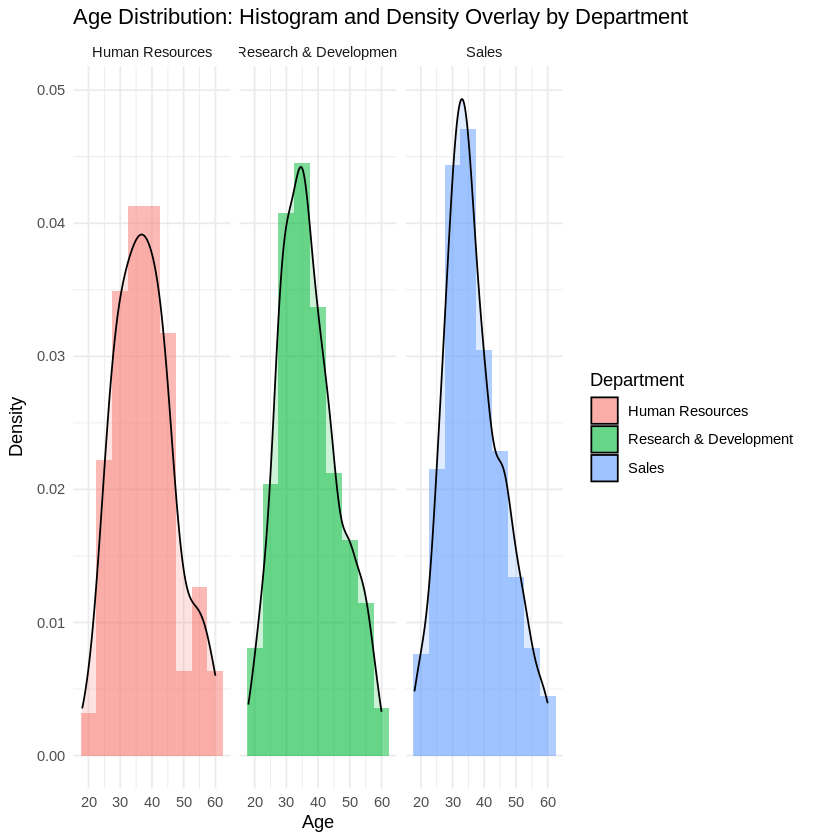

In [ ]:
ggplot(hrdata, aes(x = Age, fill = Department)) +
  geom_histogram(aes(y = ..density..),      # histogram scaled to density
                 binwidth = 5,              # adjust bin width as needed
                 alpha = 0.5,               # make bars semi-transparent
                 position = position_dodge(width = 6)) +   # bars overlap, not stacked
  geom_density(alpha = 0.2) +                # smooth density curve with some transparency
  facet_wrap(~ Department) +                  # separate panel per department
  labs(title = "Age Distribution: Histogram and Density Overlay by Department",
       y = "Density") +
  theme_minimal()

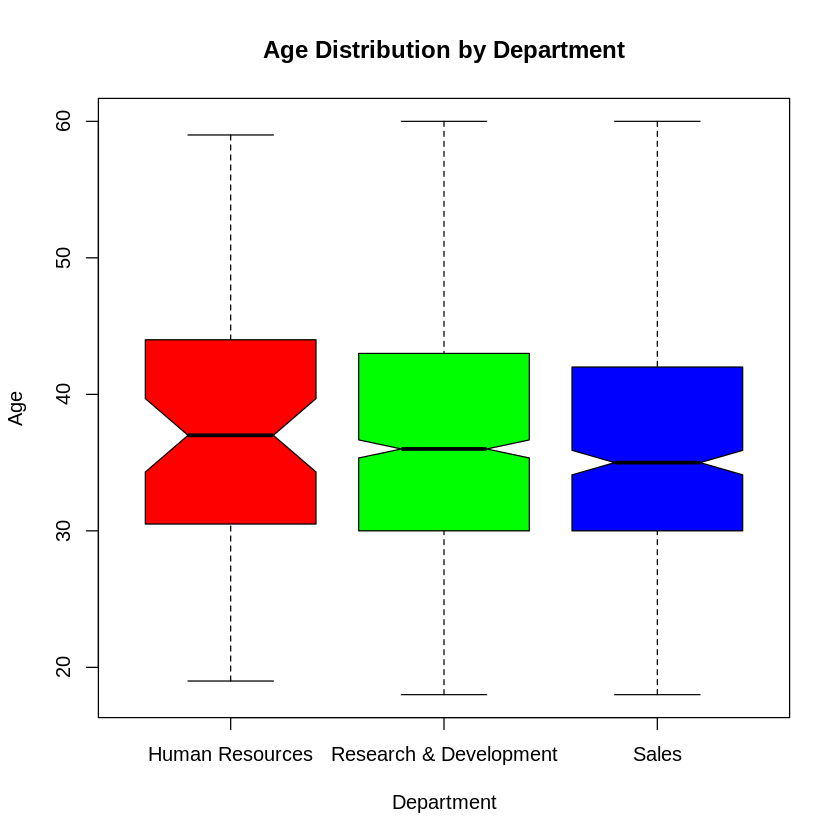

In [ ]:
boxplot(Age ~ Department, data = hrdata,
        main = "Age Distribution by Department",
        xlab = "Department",
        ylab = "Age",
        col = rainbow(length(unique(hrdata$Department))),
        notch = TRUE)  # notch adds confidence interval around median

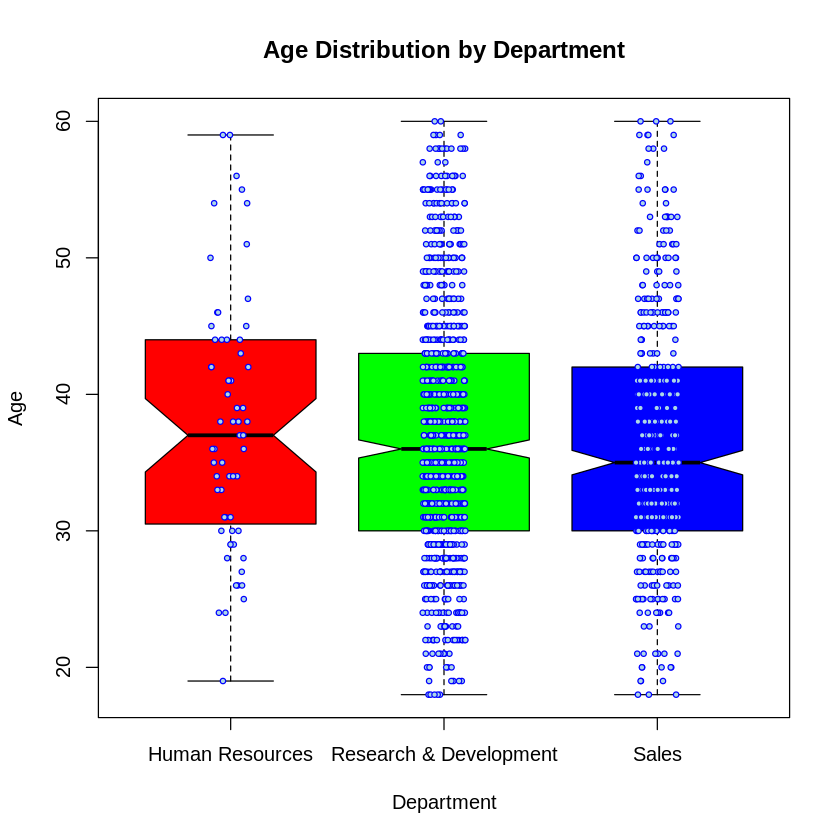

In [ ]:
boxplot(Age ~ Department, data = hrdata,
        main = "Age Distribution by Department",
        xlab = "Department",
        ylab = "Age",
        col = rainbow(length(unique(hrdata$Department))),
        notch = TRUE)
stripchart(Age ~ Department, data = hrdata,
           vertical = TRUE,
           method = "jitter",
           add = TRUE,
           pch = 21,
           col = 'blue',
           bg = 'lightblue',
           cex = 0.6)

## How to Decide Which Outliers to Look For in a Large Dataset

With 24 columns in your HR dataset, the question “Which outliers should I look for?” is very important. Outliers are unusual values that stand out and might affect your analysis or models.

---

### 1. Focus on Numeric Variables Relevant to Your Question

Outliers usually make sense to check in **numeric columns** where extreme values can skew results or indicate data errors. Examples in your dataset include:

- Age  
- DailyRate  
- DistanceFromHome  
- HourlyRate  
- MonthlyIncome  
- MonthlyRate  
- NumCompaniesWorked  
- PercentSalaryHike  
- TotalWorkingYears  
- TrainingTimesLastYear  
- YearsAtCompany  
- YearsInCurrentRole  
- YearsSinceLastPromotion  
- YearsWithCurrManager  

---

### 2. Choose Variables Most Impactful to Your Analysis

If you’re analyzing **employee attrition** or **performance**, variables like:

- MonthlyIncome  
- YearsAtCompany  
- TotalWorkingYears  
- PercentSalaryHike  

might be particularly important to check for outliers.

---

### 3. Check for Outliers in Predictor and Outcome Variables

- If you plan to **model attrition**, look at outliers in:  
  - Predictors (like `MonthlyIncome`)  
  - Outcome variables (`Attrition` is categorical but sometimes linked with numeric ones)  

---

### 4. Look at Multivariate Outliers

- Sometimes a combination of variables together can be unusual even if each variable alone looks fine.  
- Techniques like **Mahalanobis distance** or **clustering** can help detect these but are more advanced.

---

### Quick Example: How to Check Outliers Across Multiple Numeric Columns

Here’s a snippet to quickly summarize outliers in several numeric columns using the IQR method:

```r
numeric_cols <- c("Age", "DailyRate", "DistanceFromHome", "HourlyRate", "MonthlyIncome",
                  "MonthlyRate", "NumCompaniesWorked", "PercentSalaryHike", "TotalWorkingYears",
                  "TrainingTimesLastYear", "YearsAtCompany", "YearsInCurrentRole",
                  "YearsSinceLastPromotion", "YearsWithCurrManager")

outlier_summary <- sapply(hrdata[numeric_cols], function(x) {
  qnt <- quantile(x, probs=c(.25, .75), na.rm=TRUE)
  H <- 1.5 * IQR(x, na.rm=TRUE)
  sum(x < (qnt[1] - H) | x > (qnt[2] + H), na.rm=TRUE)
})

print(outlier_summary)

In [ ]:
numeric_cols <- c("Age", "DailyRate", "DistanceFromHome", "HourlyRate", "MonthlyIncome",
                  "MonthlyRate", "NumCompaniesWorked", "PercentSalaryHike", "TotalWorkingYears",
                  "TrainingTimesLastYear", "YearsAtCompany", "YearsInCurrentRole",
                  "YearsSinceLastPromotion", "YearsWithCurrManager")

outlier_summary <- sapply(hrdata[numeric_cols], function(x) {
  qnt <- quantile(x, probs=c(.25, .75), na.rm=TRUE)
  H <- 1.5 * IQR(x, na.rm=TRUE)
  sum(x < (qnt[1] - H) | x > (qnt[2] + H), na.rm=TRUE)
})

print(outlier_summary)

                    Age               DailyRate        DistanceFromHome 
                      0                       0                       0 
             HourlyRate           MonthlyIncome             MonthlyRate 
                      0                     114                       0 
     NumCompaniesWorked       PercentSalaryHike       TotalWorkingYears 
                     52                       0                      63 
  TrainingTimesLastYear          YearsAtCompany      YearsInCurrentRole 
                    238                     104                      21 
YearsSinceLastPromotion    YearsWithCurrManager 
                    107                      14 


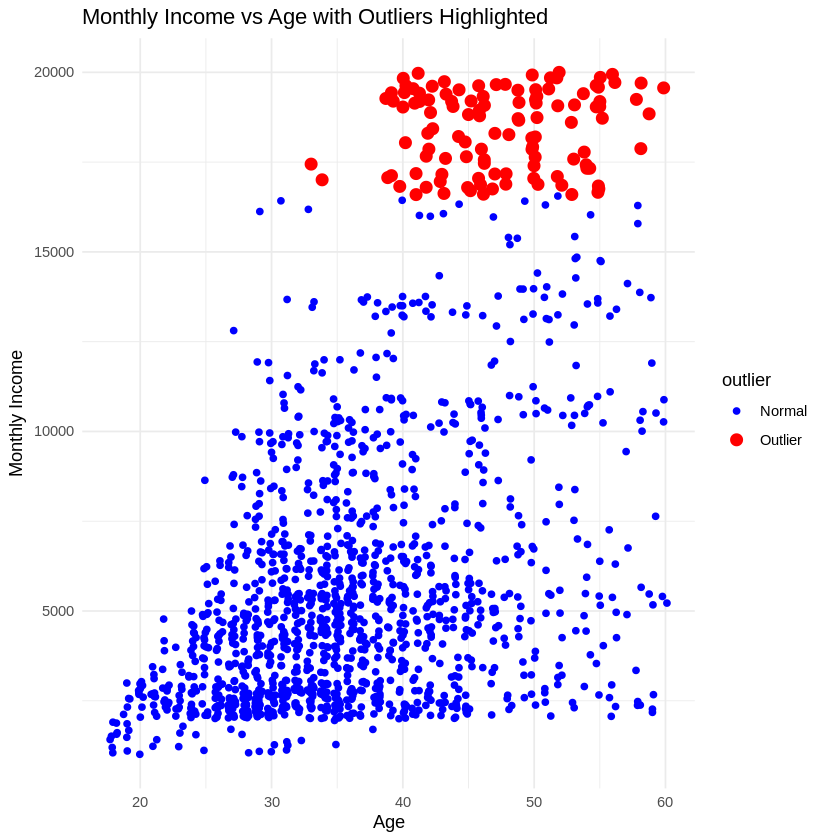

In [ ]:
library(ggplot2)

# Example: Using the HR dataset, let's say we want to plot MonthlyIncome vs Age
# and highlight outliers in MonthlyIncome

# Define outliers as points beyond 1.5 * IQR (common rule)
iqr <- IQR(hrdata$MonthlyIncome, na.rm = TRUE)
q1 <- quantile(hrdata$MonthlyIncome, 0.25, na.rm = TRUE)
q3 <- quantile(hrdata$MonthlyIncome, 0.75, na.rm = TRUE)
lower_bound <- q1 - 1.5 * iqr
upper_bound <- q3 + 1.5 * iqr

# Create a new column indicating outliers
hrdata$outlier <- ifelse(hrdata$MonthlyIncome < lower_bound | hrdata$MonthlyIncome > upper_bound, "Outlier", "Normal")

# Plot with jitter, color and size by outlier status
ggplot(hrdata, aes(x = Age, y = MonthlyIncome, color = outlier, size = outlier)) +
  geom_jitter(width = 0.3, height = 0) +
  scale_color_manual(values = c("Normal" = "blue", "Outlier" = "red")) +
  scale_size_manual(values = c("Normal" = 1.5, "Outlier" = 3)) +
  theme_minimal() +
  labs(title = "Monthly Income vs Age with Outliers Highlighted",
       x = "Age",
       y = "Monthly Income")



## Now we are looking at multiple columns with outlier altogether:

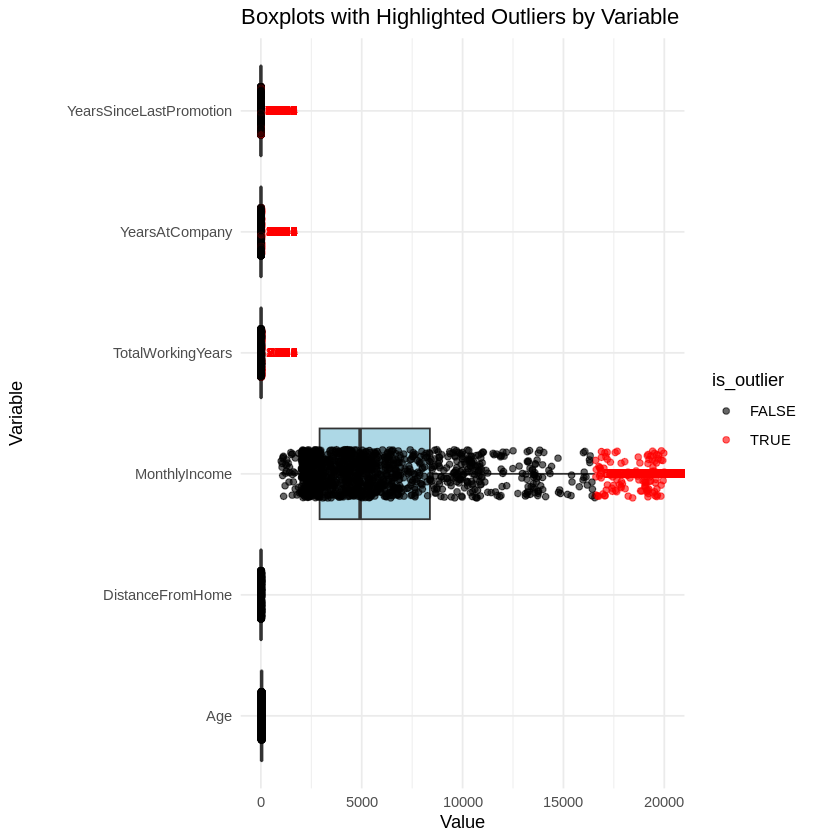

In [ ]:
library(tidyr)
library(dplyr)
library(ggplot2)

# Select numeric columns and add ID to trace back (like EmployeeNumber)
numeric_cols <- c("EmployeeNumber", "Age", "MonthlyIncome", "DistanceFromHome",
                  "TotalWorkingYears", "YearsAtCompany", "YearsSinceLastPromotion")

# Subset and pivot longer
hr_long <- hrdata %>%
  select(all_of(numeric_cols)) %>%
  pivot_longer(-EmployeeNumber, names_to = "Variable", values_to = "Value")

# Compute outlier thresholds (IQR rule)
hr_outliers <- hr_long %>%
  group_by(Variable) %>%
  mutate(
    Q1 = quantile(Value, 0.25, na.rm = TRUE),
    Q3 = quantile(Value, 0.75, na.rm = TRUE),
    IQR = Q3 - Q1,
    is_outlier = Value < (Q1 - 1.5 * IQR) | Value > (Q3 + 1.5 * IQR)
  )

# Plot with outliers highlighted and labeled
ggplot(hr_outliers, aes(x = Variable, y = Value)) +
  geom_boxplot(outlier.shape = NA, fill = "lightblue") +
  geom_jitter(aes(color = is_outlier), width = 0.2, size = 1.5, alpha = 0.6) +
  geom_text(data = filter(hr_outliers, is_outlier),
            aes(label = EmployeeNumber), hjust = -0.3, size = 2.5, color = "red") +
  coord_flip() +
  labs(title = "Boxplots with Highlighted Outliers by Variable",
       y = "Value", x = "Variable") +
  scale_color_manual(values = c("FALSE" = "black", "TRUE" = "red")) +
  theme_minimal()

## Or a side by side comparison:

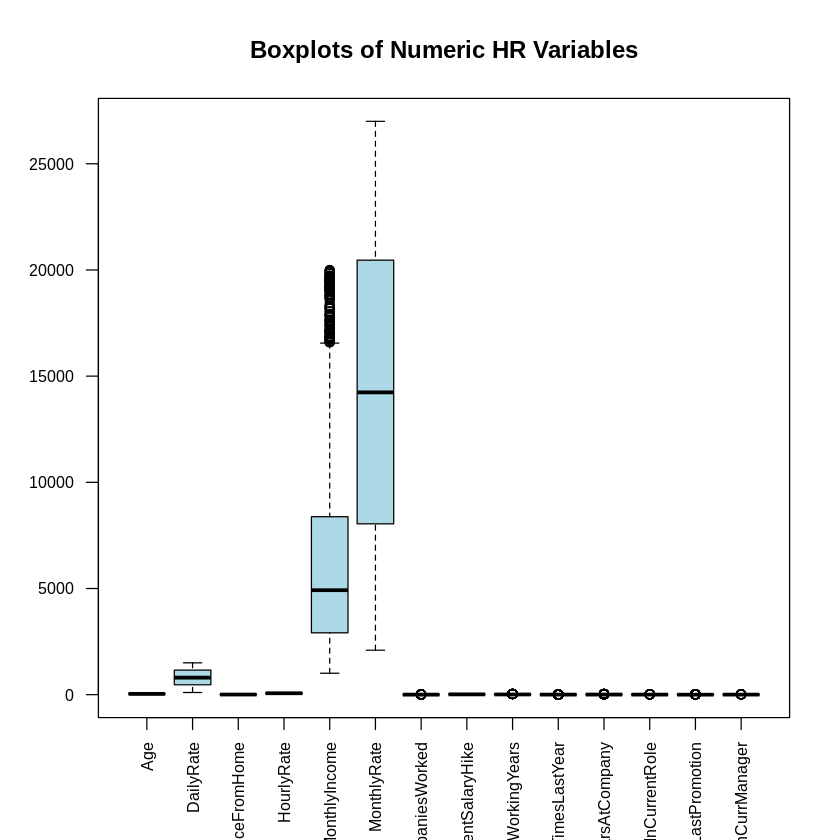

In [ ]:
# Select numeric columns
numeric_cols <- c("Age", "DailyRate", "DistanceFromHome", "HourlyRate", "MonthlyIncome",
                  "MonthlyRate", "NumCompaniesWorked", "PercentSalaryHike", "TotalWorkingYears",
                  "TrainingTimesLastYear", "YearsAtCompany", "YearsInCurrentRole",
                  "YearsSinceLastPromotion", "YearsWithCurrManager")

# Create side-by-side boxplots
boxplot(hrdata[numeric_cols],
        main = "Boxplots of Numeric HR Variables",
        las = 2,         # rotate x-axis labels
        col = "lightblue",
        outline = TRUE,  # show outliers
        cex.axis = 0.8)  # shrink axis labels


In [ ]:
cor(hrdata[, c("Age", "DailyRate", "DistanceFromHome", "Education", "HourlyRate", "MonthlyIncome", "MonthlyRate", "NumCompaniesWorked", "TotalWorkingYears", "TrainingTimesLastYear")])

,Age,DailyRate,DistanceFromHome,Education,HourlyRate,MonthlyIncome,MonthlyRate,NumCompaniesWorked,TotalWorkingYears,TrainingTimesLastYear
Age,1.00000000,0.010660943,-0.001686120,0.20803373,0.024286543,0.497854567,0.028051167,0.29963476,0.680380536,-0.019620819
DailyRate,0.01066094,1.000000000,-0.004985337,-0.01680643,0.023381422,0.007707059,-0.032181602,0.03815343,0.014514739,0.002452543
DistanceFromHome,-0.00168612,-0.004985337,1.000000000,0.02104183,0.031130586,-0.017014445,0.027472864,-0.02925080,0.004628426,-0.036942234
Education,0.20803373,-0.016806433,0.021041826,1.00000000,0.016774829,0.094960677,-0.026084197,0.12631656,0.148279697,-0.025100241
HourlyRate,0.02428654,0.023381422,0.031130586,0.01677483,1.000000000,-0.015794304,-0.015296750,0.02215688,-0.002333682,-0.008547685
MonthlyIncome,0.49785457,0.007707059,-0.017014445,0.09496068,-0.015794304,1.000000000,0.034813626,0.14951522,0.772893246,-0.021736277
MonthlyRate,0.02805117,-0.032181602,0.027472864,-0.02608420,-0.015296750,0.034813626,1.000000000,0.01752135,0.026442471,0.001466881
NumCompaniesWorked,0.29963476,0.038153434,-0.029250804,0.12631656,0.022156883,0.149515216,0.017521353,1.00000000,0.237638590,-0.066054072
TotalWorkingYears,0.68038054,0.014514739,0.004628426,0.14827970,-0.002333682,0.772893246,0.026442471,0.23763859,1.000000000,-0.035661571
TrainingTimesLastYear,-0.01962082,0.002452543,-0.036942234,-0.02510024,-0.008547685,-0.021736277,0.001466881,-0.06605407,-0.035661571,1.000000000


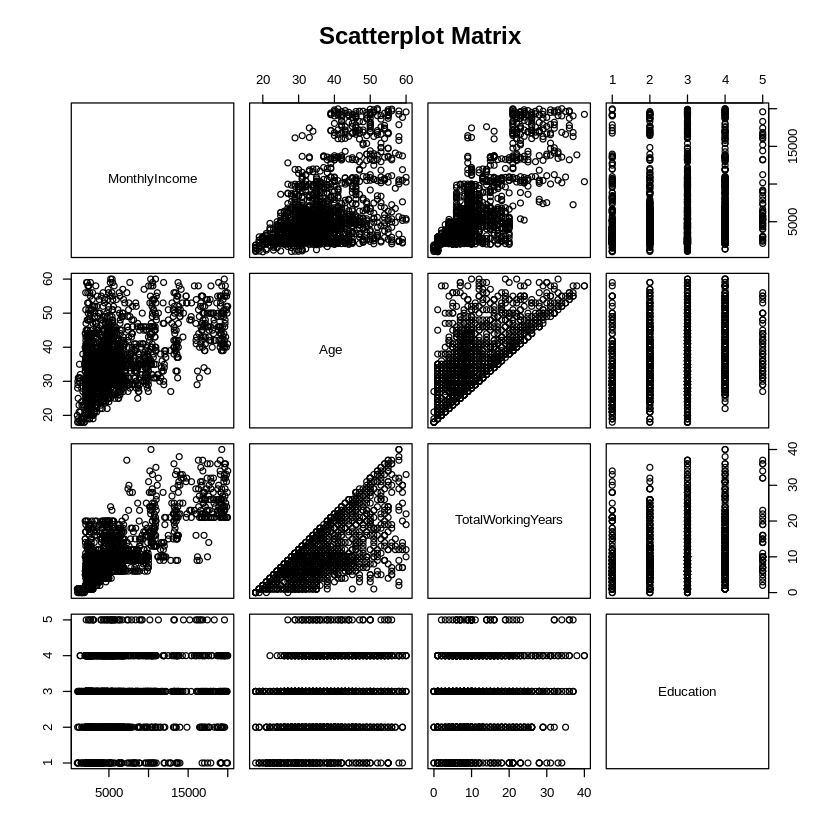

In [ ]:
pairs(~MonthlyIncome+Age+TotalWorkingYears+Education, data = hrdata, main="Scatterplot Matrix")

In [ ]:
yes_age <- hrdata[(hrdata$Attrition == "Yes"), 'Age']

In [ ]:
no_age <- hrdata[(hrdata$Attrition != "Yes"), 'Age']

In [ ]:
t.test(yes_age, no_age)


	Welch Two Sample t-test

data:  yes_age and no_age
t = -5.828, df = 316.93, p-value = 1.38e-08
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -5.288346 -2.618930
sample estimates:
mean of x mean of y 
 33.60759  37.56123 


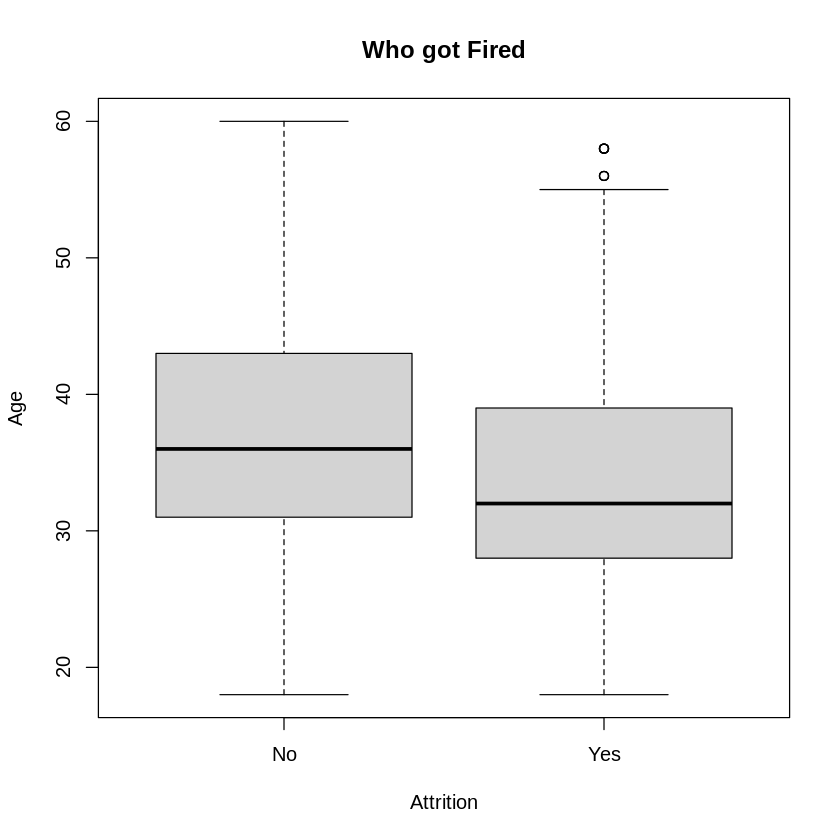

In [ ]:
boxplot(Age ~ Attrition , data = hrdata, main ="Who got Fired", xlab = "Attrition", ylab= "Age")

In [ ]:
yes_comp <- hrdata[(hrdata$Attrition == "Yes"),'EmployeeNumber']

In [ ]:
no_comp <- hrdata[(hrdata$Attrition != "Yes"), 'EmployeeNumber']

In [ ]:
t.test(yes_comp, no_comp)


	Welch Two Sample t-test

data:  yes_comp and no_comp
t = -0.41725, df = 342.33, p-value = 0.6768
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -98.91087  64.29061
sample estimates:
mean of x mean of y 
 1010.346  1027.656 


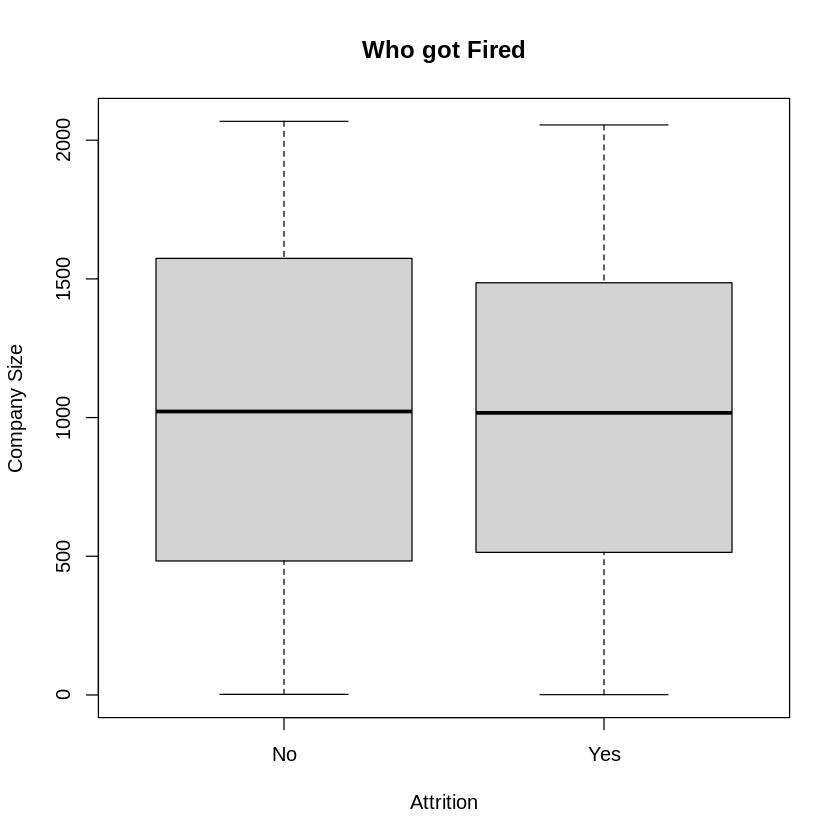

In [ ]:
boxplot(EmployeeNumber ~ Attrition , data = hrdata, main ="Who got Fired", xlab = "Attrition", ylab= "Company Size")

In [ ]:
model1 = lm(MonthlyIncome ~ Age, data = hrdata)
summary(model1)


Call:
lm(formula = MonthlyIncome ~ Age, data = hrdata)

Residuals:
    Min      1Q  Median      3Q     Max 
-9990.1 -2592.7  -677.9  1810.5 12540.8 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -2970.67     443.70  -6.695 3.06e-11 ***
Age           256.57      11.67  21.995  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4084 on 1468 degrees of freedom
Multiple R-squared:  0.2479,	Adjusted R-squared:  0.2473 
F-statistic: 483.8 on 1 and 1468 DF,  p-value: < 2.2e-16


In [ ]:
model2 = lm(MonthlyIncome ~ Age + TotalWorkingYears, data= hrdata)
summary(model2)


Call:
lm(formula = MonthlyIncome ~ Age + TotalWorkingYears, data = hrdata)

Residuals:
     Min       1Q   Median       3Q      Max 
-11310.8  -1690.8    -91.4   1428.3  11461.5 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)        1978.08     352.36   5.614 2.36e-08 ***
Age                 -26.87      11.63  -2.311    0.021 *  
TotalWorkingYears   489.13      13.65  35.824  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2984 on 1467 degrees of freedom
Multiple R-squared:  0.5988,	Adjusted R-squared:  0.5983 
F-statistic:  1095 on 2 and 1467 DF,  p-value: < 2.2e-16
